In [ ]:
import sqlite3
import numpy as np
import pandas as pd
from google.colab import files

# 1. Dataset-ah read pandrom (root path)
file_path = '/content/Teen_Mental_Health_Dataset.csv'
df = pd.read_csv(file_path)

# 2. NumPy & Pandas feature engineering
# Sleep debt flag: 6 hours-kku kuraiva thoonguna 1, illana 0
df['sleep_debt_flag'] = np.where(df['sleep_hours'] < 6.0, 1, 0)

# Composite Digital Risk Score (0 to 10 scale)
df['digital_risk_score'] = np.round(
    (
        (df['daily_social_media_hours'] / 8.0) * 0.4
        + (df['screen_time_before_sleep'] / 3.0) * 0.3
        + (df['addiction_level'] / 10.0) * 0.3
    )
    * 10,
    2,
)

# Dashboard slicer-kaga age cohorts
bins = [12, 14, 17, 20]
labels = ['Early Teens (13-14)', 'Mid Teens (15-17)', 'Late Teens (18-19)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# High addiction flag
df['high_addiction_flag'] = np.where(df['addiction_level'] >= 7, 1, 0)

# 3. SQLite Database-la save pandrom
conn = sqlite3.connect('teen_mental_health.db')
df.to_sql('teen_records', conn, if_exists='replace', index=False)
conn.close()

# 4. Cleaned CSV export & automatic download
df.to_csv('teen_mental_health_cleaned.csv', index=False)
print('Done! Cleaned CSV download aaga start aagum.')
files.download('teen_mental_health_cleaned.csv')

Done! Cleaned CSV download aaga start aagum.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import pandas as pd
import numpy as np

# File path auto-detect
if os.path.exists('teen_mental_health_cleaned.csv'):
    file_path = 'teen_mental_health_cleaned.csv'
elif os.path.exists('Teen_Mental_Health_Dataset.csv'):
    file_path = 'Teen_Mental_Health_Dataset.csv'
else:
    file_path = '/content/Teen_Mental_Health_Dataset.csv'

df = pd.read_csv(file_path)

print("=" * 55)
print("1. DATASET STATS (NUMPY & PANDAS)")
print("=" * 55)

# NumPy summary stats
metrics_table = pd.DataFrame({
    'Metric': ['Daily Social Media (hrs)', 'Sleep (hrs)', 'Screen Time Pre-Sleep (hrs)', 'Stress Level (1-10)', 'Anxiety Level (1-10)'],
    'Mean': [np.mean(df['daily_social_media_hours']), np.mean(df['sleep_hours']), np.mean(df['screen_time_before_sleep']), np.mean(df['stress_level']), np.mean(df['anxiety_level'])],
    'Median': [np.median(df['daily_social_media_hours']), np.median(df['sleep_hours']), np.median(df['screen_time_before_sleep']), np.median(df['stress_level']), np.median(df['anxiety_level'])],
    'Std Dev': [np.std(df['daily_social_media_hours']), np.std(df['sleep_hours']), np.std(df['screen_time_before_sleep']), np.std(df['stress_level']), np.std(df['anxiety_level'])]
}).round(2)

print(metrics_table.to_string(index=False))

# Pandas Groupby: Platform usage comparison
print("\n" + "=" * 55)
print("2. PLATFORM USAGE VS MENTAL HEALTH")
print("=" * 55)
platform_grp = df.groupby('platform_usage').agg(
    total_teens=('age', 'count'),
    avg_social_hrs=('daily_social_media_hours', 'mean'),
    avg_sleep_hrs=('sleep_hours', 'mean'),
    avg_stress=('stress_level', 'mean'),
    avg_anxiety=('anxiety_level', 'mean')
).round(2)
print(platform_grp)

1. DATASET STATS (NUMPY & PANDAS)
                     Metric  Mean  Median  Std Dev
   Daily Social Media (hrs)  4.54     4.5     2.03
                Sleep (hrs)  6.45     6.5     1.44
Screen Time Pre-Sleep (hrs)  1.74     1.8     0.72
        Stress Level (1-10)  5.45     5.0     2.90
       Anxiety Level (1-10)  5.64     6.0     2.86

2. PLATFORM USAGE VS MENTAL HEALTH
                total_teens  avg_social_hrs  avg_sleep_hrs  avg_stress  \
platform_usage                                                           
Both                    391            4.52           6.46        5.55   
Instagram               411            4.56           6.44        5.50   
TikTok                  398            4.53           6.45        5.29   

                avg_anxiety  
platform_usage               
Both                   5.49  
Instagram              5.67  
TikTok                 5.75  


In [ ]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect('teen_mental_health.db')

print("=" * 60)
print("SQL QUERY 1: PLATFORM IMPACT BREAKDOWN")
print("=" * 60)
q1 = """
SELECT
    platform_usage,
    COUNT(*) AS total_students,
    ROUND(AVG(daily_social_media_hours), 2) AS avg_screen_hours,
    ROUND(AVG(sleep_hours), 2) AS avg_sleep_hours,
    ROUND(AVG(stress_level), 2) AS avg_stress_score,
    ROUND(AVG(anxiety_level), 2) AS avg_anxiety_score
FROM teen_records
GROUP BY platform_usage
ORDER BY avg_stress_score DESC;
"""
print(pd.read_sql_query(q1, conn).to_string(index=False))

print("\n" + "=" * 60)
print("SQL QUERY 2: AGE COHORT & GENDER BREAKDOWN")
print("=" * 60)
q2 = """
SELECT
    age_group,
    gender,
    COUNT(*) AS student_count,
    ROUND(AVG(daily_social_media_hours), 2) AS avg_screen_hours,
    ROUND(AVG(academic_performance), 2) AS avg_gpa,
    ROUND(AVG(digital_risk_score), 2) AS avg_risk_score
FROM teen_records
GROUP BY age_group, gender
ORDER BY age_group, gender;
"""
print(pd.read_sql_query(q2, conn).to_string(index=False))

print("\n" + "=" * 60)
print("SQL QUERY 3: TOP 25% SCREEN USAGE RISK SEGMENT (CTE + NTILE)")
print("=" * 60)
q3 = """
WITH ScreenQuartiles AS (
    SELECT
        platform_usage,
        age_group,
        sleep_hours,
        stress_level,
        addiction_level,
        sleep_debt_flag,
        NTILE(4) OVER (ORDER BY daily_social_media_hours DESC) AS usage_quartile
    FROM teen_records
)
SELECT
    age_group,
    COUNT(*) AS high_screen_users,
    SUM(sleep_debt_flag) AS sleep_deprived_count,
    ROUND(AVG(stress_level), 2) AS avg_stress,
    ROUND(AVG(addiction_level), 2) AS avg_addiction
FROM ScreenQuartiles
WHERE usage_quartile = 1
GROUP BY age_group
ORDER BY avg_stress DESC;
"""
print(pd.read_sql_query(q3, conn).to_string(index=False))

conn.close()

SQL QUERY 1: PLATFORM IMPACT BREAKDOWN
platform_usage  total_students  avg_screen_hours  avg_sleep_hours  avg_stress_score  avg_anxiety_score
          Both             391              4.52             6.46              5.55               5.49
     Instagram             411              4.56             6.44              5.50               5.67
        TikTok             398              4.53             6.45              5.29               5.75

SQL QUERY 2: AGE COHORT & GENDER BREAKDOWN
          age_group gender  student_count  avg_screen_hours  avg_gpa  avg_risk_score
Early Teens (13-14) female            171              4.31     3.01            5.56
Early Teens (13-14)   male            182              4.56     3.02            5.59
 Late Teens (18-19) female            151              4.47     3.03            5.77
 Late Teens (18-19)   male            183              4.30     2.97            5.69
  Mid Teens (15-17) female            263              4.67     2.98            

1. OUTLIER DETECTION (IQR METHOD)
daily_social_media_hours: 0 outliers detected (Normal range: -2.45 to 11.55)
sleep_hours: 0 outliers detected (Normal range: 1.60 to 11.20)
academic_performance: 0 outliers detected (Normal range: 1.03 to 4.95)

2. STATISTICAL HYPOTHESIS TESTING (T-TEST)
Sleep Deprived Avg Stress: 5.50
Normal Sleep Avg Stress:   5.41
T-statistic: 0.4870 | P-value: 6.2638e-01
Result: No significant variance detected.

3. ADVANCED SQL (DENSE_RANK & PIVOT MATRIX)
--- Top Risk Students Per Platform (Window Function) ---
platform_usage  age gender  daily_social_media_hours  stress_level  digital_risk_score
          Both   18   male                       7.9             1                9.65
          Both   13 female                       7.3             6                9.35
     Instagram   13 female                       8.0             6                9.80
     Instagram   17 female                       7.6             4                9.70
        TikTok   16   male

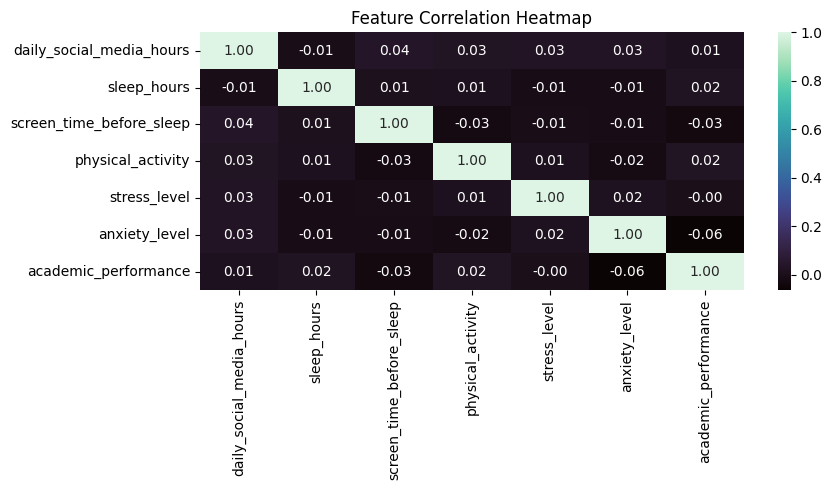

Heatmap generated and saved as correlation_heatmap.png


In [ ]:
import os
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# 1. Load Data
df = pd.read_csv('teen_mental_health_cleaned.csv')

print('=' * 60)
print('1. OUTLIER DETECTION (IQR METHOD)')
print('=' * 60)


def check_outliers(column_name):
  q1 = np.percentile(df[column_name], 25)
  q3 = np.percentile(df[column_name], 75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outliers = df[
      (df[column_name] < lower_bound) | (df[column_name] > upper_bound)
  ]
  print(
      f'{column_name}: {len(outliers)} outliers detected (Normal range:'
      f' {lower_bound:.2f} to {upper_bound:.2f})'
  )


check_outliers('daily_social_media_hours')
check_outliers('sleep_hours')
check_outliers('academic_performance')

print('\n' + '=' * 60)
print('2. STATISTICAL HYPOTHESIS TESTING (T-TEST)')
print('=' * 60)
# Hypothesis: Sleep deficit (<6 hrs) increases stress significantly
sleep_deprived_stress = df[df['sleep_debt_flag'] == 1]['stress_level']
normal_sleep_stress = df[df['sleep_debt_flag'] == 0]['stress_level']

t_stat, p_val = stats.ttest_ind(sleep_deprived_stress, normal_sleep_stress)
print(f'Sleep Deprived Avg Stress: {sleep_deprived_stress.mean():.2f}')
print(f'Normal Sleep Avg Stress:   {normal_sleep_stress.mean():.2f}')
print(f'T-statistic: {t_stat:.4f} | P-value: {p_val:.4e}')
if p_val < 0.05:
  print('Result: Statistically significant impact confirmed.')
else:
  print('Result: No significant variance detected.')

print('\n' + '=' * 60)
print('3. ADVANCED SQL (DENSE_RANK & PIVOT MATRIX)')
print('=' * 60)
conn = sqlite3.connect('teen_mental_health.db')

# SQL 1: Ranking high-risk students per platform using DENSE_RANK()
sql_rank = """
WITH RiskRanked AS (
    SELECT
        platform_usage,
        age,
        gender,
        daily_social_media_hours,
        stress_level,
        digital_risk_score,
        DENSE_RANK() OVER (PARTITION BY platform_usage ORDER BY digital_risk_score DESC) as risk_rank
    FROM teen_records
)
SELECT platform_usage, age, gender, daily_social_media_hours, stress_level, digital_risk_score
FROM RiskRanked
WHERE risk_rank <= 2;
"""
print('--- Top Risk Students Per Platform (Window Function) ---')
print(pd.read_sql_query(sql_rank, conn).to_string(index=False))

# SQL 2: Conditional Pivot Matrix
sql_pivot = """
SELECT
    age_group,
    ROUND(AVG(CASE WHEN platform_usage = 'Instagram' THEN stress_level END), 2) AS insta_stress,
    ROUND(AVG(CASE WHEN platform_usage = 'TikTok' THEN stress_level END), 2) AS tiktok_stress,
    ROUND(AVG(CASE WHEN platform_usage = 'Both' THEN stress_level END), 2) AS both_stress
FROM teen_records
GROUP BY age_group;
"""
print('\n--- Platform vs Age Group Pivot Matrix ---')
print(pd.read_sql_query(sql_pivot, conn).to_string(index=False))
conn.close()

# 4. Generate GitHub Visual (Correlation Heatmap)
plt.figure(figsize=(9, 5))
corr_cols = [
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'physical_activity',
    'stress_level',
    'anxiety_level',
    'academic_performance',
]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='mako', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()
print('Heatmap generated and saved as correlation_heatmap.png')

In [ ]:
from google.colab import files

# Ella output files-ayum local computer-ku download pandrom
files.download('teen_mental_health_cleaned.csv')
files.download('teen_mental_health.db')
files.download('correlation_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>